In [18]:
%pip install geopandas shapely geopy requests

Note: you may need to restart the kernel to use updated packages.


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import time
import geopandas as gpd
from shapely.geometry import Point
from geopy.geocoders import Nominatim
import re

In [20]:
import random

In [21]:
df = pd.read_excel("C:/Реестр (1).xlsx",  header=1)

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [22]:
df_new = df.loc[1:, :]
df_new.columns =['№ п/п', 'Наименование / ФИО', 'Тип субъекта', 'Категория',
              'ОГРН', 'ИНН', 'Основной вид деятельности', 'Регион',
              'Район', 'Город', 'Населенный пункт', 'Вновь созданный', 'Дата включения в реестр', 'Дата исключения из реестра',
                 'Телефон', 'E-mail', 'WWW', 'Наличие лицензий', 'Наличие заключенных договоров, контрактов',
                 'Производство инновационных, высокотехнологичной продукции', 'Участие в программах партнерства', 'Является социальным прдприятием',
                 'Среднесписочная численность работников за предшествующий календарный год']

In [23]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 603520 entries, 1 to 603520
Data columns (total 23 columns):
 #   Column                                                                    Non-Null Count   Dtype 
---  ------                                                                    --------------   ----- 
 0   № п/п                                                                     603520 non-null  object
 1   Наименование / ФИО                                                        603520 non-null  object
 2   Тип субъекта                                                              603520 non-null  object
 3   Категория                                                                 603520 non-null  object
 4   ОГРН                                                                      603520 non-null  object
 5   ИНН                                                                       603520 non-null  object
 6   Основной вид деятельности                                   

In [24]:
df_new.head()

,№ п/п,Наименование / ФИО,Тип субъекта,Категория,ОГРН,ИНН,Основной вид деятельности,Регион,Район,Город,...,Дата исключения из реестра,Телефон,E-mail,WWW,Наличие лицензий,"Наличие заключенных договоров, контрактов","Производство инновационных, высокотехнологичной продукции",Участие в программах партнерства,Является социальным прдприятием,Среднесписочная численность работников за предшествующий календарный год
1,1,""" МЕГАПОЛИС "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВ...",Юридическое лицо,Не является субъектом МСП,1027800523376,7801190028,41.2 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.10.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
2,2,""" СТАЛЬИНВЕСТСТРОЙ "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1037800033545,7801227976,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.08.2018,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
3,3,""" СТРОЙТЕХНИКА - М "" ОБЩЕСТВО С ОГРАНИЧЕННОЙ О...",Юридическое лицо,Не является субъектом МСП,1025204418293,5263039399,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,10.07.2022,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN
4,4,"""БАЗИС"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Микропредприятие,1025204411682,5263025484,41.20 Строительство жилых и нежилых зданий,52 - Нижегородская область,NaN,г Нижний Новгород,...,NaN,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,1
5,5,"""БЕЛАГ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",Юридическое лицо,Не является субъектом МСП,1037800039276,7801123215,41.20 Строительство жилых и нежилых зданий,78 - г.Санкт-Петербург,NaN,NaN,...,10.07.2021,NaN,NaN,NaN,Нет,Нет,Нет,Нет,Нет,NaN


In [25]:
df_new.shape

(603520, 23)

In [26]:
df_new = df_new[df_new["Тип субъекта"] == "Юридическое лицо"]
df_new = df_new[df_new["Категория"].isin(["Малое предприятие", "Среднее предприятие"])]
df_new = df_new[df_new["Основной вид деятельности"].str.startswith("41.20", na=False)]

In [27]:
df_new["ИНН"].head()

20      5038038838
52      5027006369
4653    1414006922
4668    3327332190
4674    7816061297
Name: ИНН, dtype: object

In [28]:
df_new.shape

(8927, 23)

In [29]:
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8927 entries, 20 to 580135
Data columns (total 23 columns):
 #   Column                                                                    Non-Null Count  Dtype 
---  ------                                                                    --------------  ----- 
 0   № п/п                                                                     8927 non-null   object
 1   Наименование / ФИО                                                        8927 non-null   object
 2   Тип субъекта                                                              8927 non-null   object
 3   Категория                                                                 8927 non-null   object
 4   ОГРН                                                                      8927 non-null   object
 5   ИНН                                                                       8927 non-null   object
 6   Основной вид деятельности                                                 

In [30]:
df_new = df_new.drop(columns = ["Дата исключения из реестра", "WWW", "E-mail", "Телефон", "Населенный пункт"])

Взяла первые 2000, очень долго считает

In [45]:
df_new = df_new.head(2000)

In [ ]:
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
    'Accept': 'application/json'
})

inn_list = df_new["ИНН"].astype(str).tolist()  
all_results = []

for inn in inn_list:
    
    res1 = session.get(f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0", timeout=40)
    
    data1 = res1.json()
    if not data1.get("content") or len(data1["content"]) == 0:
        continue 
     
    org_id = data1["content"][0]["id"]
    res2 = session.get(f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo", timeout=40)  
    reports = res2.json()
    
  
    for report in reports:
        
        type_corrections = report.get("typeCorrections")
        if not type_corrections or len(type_corrections) == 0:
            continue
            
        correction = type_corrections[0].get("correction")
        if correction is None:
            continue
            
        fin = correction.get("financialResult")
        if fin is None:
            continue
            
        net_profit_2400 = fin.get("current2400")
        if net_profit_2400 is None:
            continue
            
        revenue_2110 = fin.get("current2110")
        if revenue_2110 is None:
            continue
        
        # Прибыль до налогообложения (строка 2300)
        profit_before_tax_2300 = fin.get("current2300")
        if profit_before_tax_2300 is None:
            continue
            
        # Проценты к уплате (строка 2330)
        interest_2330 = fin.get("current2330") or 0
        
        # Прибыль от продаж текущая и предыдущая (для расчета амортизации)
        #operating_profit_current = fin.get("current2200")
        #operating_profit_previous = fin.get("previous2200")
        
        #if operating_profit_current is None:
        #   continue
        
        # Амортизация = разница между предыдущим и текущим значением прибыли от продаж
        #if operating_profit_previous is not None:
        #    depreciation = operating_profit_previous - operating_profit_current
        #else:
        #    depreciation = 0
            
        funds_movement = correction.get("fundsMovement")
        depreciation = 0
    
        if funds_movement is not None:
            depreciation = funds_movement.get("current4110") or 0
           
        # Убеждаемся что амортизация >= 0
        depreciation = max(0, depreciation)
        
        ebita = profit_before_tax_2300 + interest_2330 + depreciation
        
        year = int(report.get("period"))
        
        all_results.append({
            "ИНН": inn,
            "Год": year,
            "EBITA": ebita,
            "Чистая_прибыль": net_profit_2400,
            "Выручка": revenue_2110,
            "Прибыль_до_налогов": profit_before_tax_2300,
            "Проценты_к_уплате": interest_2330,
            "Амортизация": depreciation,
        })
        
        
    time.sleep(random.uniform(1, 4))  

In [32]:
session = requests.Session()
session.headers.update({
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'application/json',
    'Connection': 'close'  
})

inn_list = df_new["ИНН"].astype(str).tolist()  
all_results = []
processed_count = 0  

for inn in inn_list:
    processed_count += 1
    
    try:  
        res1 = session.get(f"https://bo.nalog.gov.ru/advanced-search/organizations/search?query={inn}&page=0", timeout=15)
        res1.raise_for_status()
        
        data1 = res1.json()
        if not data1.get("content") or len(data1["content"]) == 0:
            continue 
         
        org_id = data1["content"][0]["id"]
        
        res2 = session.get(f"https://bo.nalog.gov.ru/nbo/organizations/{org_id}/bfo", timeout=15)  
        res2.raise_for_status()
        reports = res2.json()
      
        for report in reports:
            type_corrections = report.get("typeCorrections")
            if not type_corrections or len(type_corrections) == 0:
                continue
                
            correction = type_corrections[0].get("correction")
            if correction is None:
                continue
                
            fin = correction.get("financialResult")
            if fin is None:
                continue
                
            net_profit_2400 = fin.get("current2400")
            if net_profit_2400 is None:
                continue
                
            revenue_2110 = fin.get("current2110")
            if revenue_2110 is None:
                continue
            
            profit_before_tax_2300 = fin.get("current2300")
            if profit_before_tax_2300 is None:
                continue
                
            interest_2330 = fin.get("current2330") or 0
            
            funds_movement = correction.get("fundsMovement")
            depreciation = 0
        
            if funds_movement is not None:
                depreciation = funds_movement.get("current4110") or 0
           
            depreciation = max(0, depreciation)
            
            ebita = profit_before_tax_2300 + interest_2330 + depreciation
            
            year = int(report.get("period"))
            
            all_results.append({
                "ИНН": inn,
                "Год": year,
                "EBITA": ebita,
                "Чистая_прибыль": net_profit_2400,
                "Выручка": revenue_2110,
                "Прибыль_до_налогов": profit_before_tax_2300,
                "Проценты_к_уплате": interest_2330,
                "Амортизация": depreciation,
            })
            
    except Exception:
        continue
    
    time.sleep(random.uniform(0.5, 1.5))   
   
    if processed_count % 100 == 0:
        df_temp = pd.DataFrame(all_results)
        df_temp.to_csv('progress_save.csv', index=False, encoding='utf-8-sig')
        print(f"{processed_count} из {len(inn_list)}. Найдено записей: {len(all_results)}")

df_temp = pd.DataFrame(all_results)
df_temp.to_csv('financial_data_final.csv', index=False, encoding='utf-8-sig')

100 из 1000. Найдено записей: 402
200 из 1000. Найдено записей: 831
300 из 1000. Найдено записей: 1220
400 из 1000. Найдено записей: 1508
500 из 1000. Найдено записей: 1758
600 из 1000. Найдено записей: 1988
700 из 1000. Найдено записей: 2224
800 из 1000. Найдено записей: 2459
900 из 1000. Найдено записей: 2669
1000 из 1000. Найдено записей: 2924


In [33]:
print(f"Всего записей: {len(df_temp)}")
print(f"Записей с отрицательной прибылью: {(df_temp['Чистая_прибыль'] < 0).sum()}")
print(f"Средняя чистая прибыль: {df_temp['Чистая_прибыль'].mean():.2f}")
print(f"Медианная чистая прибыль: {df_temp['Чистая_прибыль'].median():.2f}")
print(f"Максимальный убыток: {df_temp['Чистая_прибыль'].min():.2f}")
print(f"Максимальная прибыль: {df_temp['Чистая_прибыль'].max():.2f}")

print(f"\nКомпаний с нулевой выручкой: {(df_temp['Выручка'] == 0).sum()}")

Всего записей: 2924
Записей с отрицательной прибылью: 551
Средняя чистая прибыль: 19174.70
Медианная чистая прибыль: 2398.00
Максимальный убыток: -3503598.00
Максимальная прибыль: 2429778.00

Компаний с нулевой выручкой: 81


In [34]:
zero_revenue = df_temp[df_temp['Выручка'] == 0]

print("Примеры компаний с нулевой выручкой:")
print(zero_revenue[['ИНН', 'Год', 'EBITA', 'Чистая_прибыль', 'Выручка']].head(10))

print(f"\nС прибылью: {(zero_revenue['Чистая_прибыль'] > 0).sum()}")
print(f"С убытком: {(zero_revenue['Чистая_прибыль'] < 0).sum()}")
print(f"С нулевой прибылью: {(zero_revenue['Чистая_прибыль'] == 0).sum()}")

Примеры компаний с нулевой выручкой:
            ИНН   Год     EBITA  Чистая_прибыль  Выручка
66   7810255553  2025  952948.0        -30655.0      0.0
80   3250057750  2024   -3846.0        -20009.0      0.0
89   7743373485  2025   -8406.0        -18777.0      0.0
115  7704697207  2022       0.0             0.0      0.0
117  7704697207  2025 -106028.0       -106028.0      0.0
138  5025012896  2024  279113.0         42263.0      0.0
236  9701004970  2025    6277.0         -3309.0      0.0
292  2108002261  2021   17051.0            18.0      0.0
371  7815014022  2024   35223.0         -5801.0      0.0
394  6316135260  2021      24.0            21.0      0.0

С прибылью: 15
С убытком: 41
С нулевой прибылью: 25


In [60]:
for col in ['EBITA', 'Чистая_прибыль', 'Выручка', 'Амортизация', 'Проценты_к_уплате']:
    print(f"\n{col}:")
    print(f"  Мин: {df_temp[col].min():,.0f}")
    print(f"  25%: {df_temp[col].quantile(0.25):,.0f}")
    print(f"  50%: {df_temp[col].quantile(0.50):,.0f}")
    print(f"  75%: {df_temp[col].quantile(0.75):,.0f}")
    print(f"  Макс: {df_temp[col].max():,.0f}")
    print(f"  Среднее: {df_temp[col].mean():,.0f}")


EBITA:
  Мин: -765,613
  25%: 4,946
  50%: 83,044
  75%: 519,643
  Макс: 14,044,376
  Среднее: 473,890

Чистая_прибыль:
  Мин: -3,503,598
  25%: 91
  50%: 2,398
  75%: 13,547
  Макс: 2,429,778
  Среднее: 19,175

Выручка:
  Мин: 0
  25%: 56,325
  50%: 178,812
  75%: 525,779
  Макс: 7,211,988
  Среднее: 427,916

Амортизация:
  Мин: 0
  25%: 0
  50%: 71,526
  75%: 489,118
  Макс: 13,601,049
  Среднее: 440,342

Проценты_к_уплате:
  Мин: -36,759
  25%: 0
  50%: 0
  75%: 916
  Макс: 4,673,051
  Среднее: 7,732


In [61]:
df_clean = df_temp.copy()
df_clean = df_clean[df_clean['Выручка'] > 0]
df_clean = df_clean[df_clean['Амортизация'] >= 0]
df_clean = df_clean[df_clean['Проценты_к_уплате'] >= 0]

print(f"Осталось записей: {len(df_clean)}")

Осталось записей: 2823


In [46]:
print(df_clean.describe())

               Год         EBITA  Чистая_прибыль       Выручка  \
count  2823.000000  2.823000e+03    2.823000e+03  2.823000e+03   
mean   2022.827134  4.891023e+05    2.009891e+04  4.405597e+05   
std       1.384285  1.009373e+06    1.557796e+05  6.469776e+05   
min    2021.000000 -7.656130e+05   -3.503598e+06  2.000000e+00   
25%    2022.000000  6.109500e+03    1.630000e+02  6.418750e+04   
50%    2023.000000  9.179300e+04    2.634000e+03  1.877920e+05   
75%    2024.000000  5.583005e+05    1.414300e+04  5.400680e+05   
max    2025.000000  1.404438e+07    2.429778e+06  7.211988e+06   

       Прибыль_до_налогов  Проценты_к_уплате   Амортизация  
count        2.823000e+03       2.823000e+03  2.823000e+03  
mean         2.692162e+04       8.031277e+03  4.541494e+05  
std          1.959517e+05       1.019143e+05  9.432080e+05  
min         -4.671320e+06       0.000000e+00  0.000000e+00  
25%          3.985000e+02       0.000000e+00  0.000000e+00  
50%          3.795000e+03       0.00000

In [52]:
df_all = df_clean.sort_values(by=["ИНН", "Год"])

N = 2 
growth_results = []


for inn, group in df_all.groupby("ИНН"):
    years = group["Год"].tolist()
    
    for i in range(len(years) - N):
        year_start = years[i]
        year_end = years[i + N]
        
        profit_start = group[group["Год"] == year_start]["Чистая_прибыль"].values[0]
        profit_end = group[group["Год"] == year_end]["Чистая_прибыль"].values[0]
        
        if profit_start == 0:
            growth_percent = None
        else:
            growth_percent = ((profit_end - profit_start) / abs(profit_start)) * 100
            
        if growth_percent is not None:
            growth_int = int(round(growth_percent))
        else:
            growth_int = None
        
        growth_results.append({
            "ИНН": inn,
            "Год_начало": year_start,
            "Год_конец": year_end,
            "Рост_прибыли_процент": growth_int
        })

df_growth = pd.DataFrame(growth_results)

In [53]:
df_growth.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ИНН                   1455 non-null   object 
 1   Год_начало            1455 non-null   int64  
 2   Год_конец             1455 non-null   int64  
 3   Рост_прибыли_процент  1451 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 45.6+ KB


In [54]:
df_growth = df_growth[df_growth['Рост_прибыли_процент'].notna()]

In [55]:
df_all_years.sort_values("Чистая_прибыль").head(100)

,ИНН,Год,EBITA,Чистая_прибыль,Выручка,Прибыль_до_налогов,Проценты_к_уплате,Амортизация
573,7705014485,2025,54200.0,-3503598.0,30190.0,-4671320.0,4673051.0,52469.0
574,7705014485,2024,-171808.0,-1634062.0,30500.0,-2352665.0,1977314.0,203543.0
572,7705014485,2023,-350289.0,-1252821.0,1513.0,-1393403.0,1041010.0,2104.0
741,5032001704,2024,-119634.0,-1076957.0,690293.0,-1346196.0,101098.0,1125464.0
2543,2466154391,2024,1437630.0,-946741.0,2063579.0,-946741.0,20041.0,2364330.0
...,...,...,...,...,...,...,...,...
257,5029014809,2021,4479.0,-53511.0,58821.0,-51305.0,2554.0,53230.0
248,6312040240,2024,1603134.0,-52053.0,1356420.0,-52053.0,9822.0,1645365.0
2049,7841022608,2021,1446744.0,-51927.0,931534.0,-55491.0,0.0,1502235.0
903,5077000274,2023,-39238.0,-51465.0,11657.0,-60241.0,3921.0,17082.0


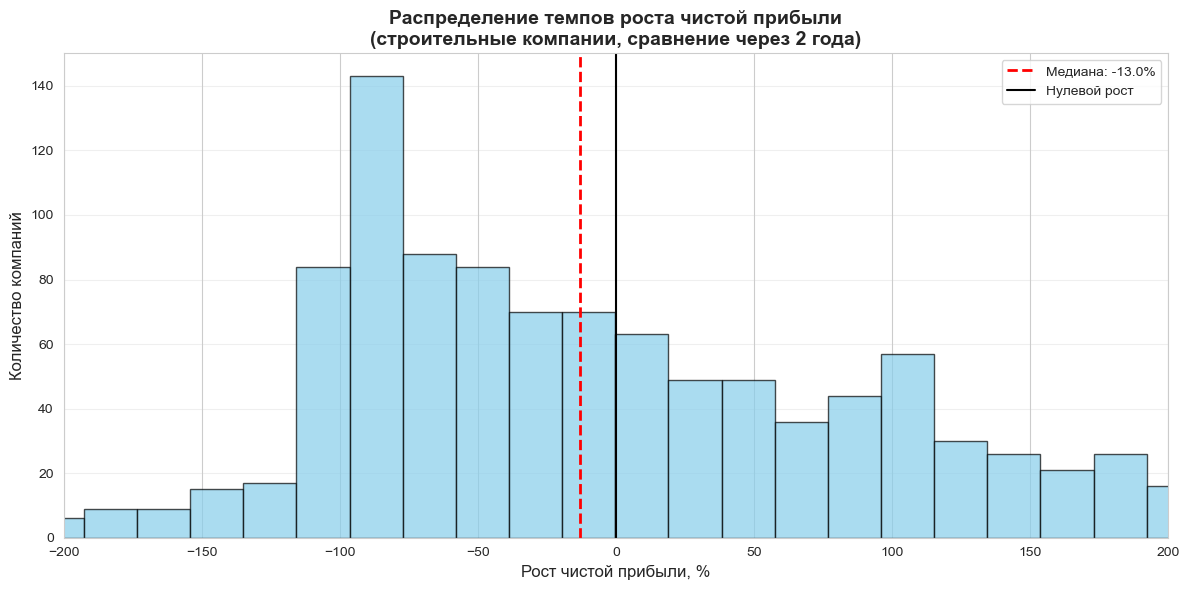

Всего сравнений (в диапазоне ±200%): 1175
Медианный рост: -13.0%
Доля компаний с ростом прибыли: 45.4%
Доля компаний с убытком: 54.0%


In [59]:
df_growth_filtered = df_growth[
    (df_growth['Рост_прибыли_процент'] >= -500) & 
    (df_growth['Рост_прибыли_процент'] <= 500)
].copy()


plt.figure(figsize=(12, 6))

plt.hist(
    df_growth_filtered['Рост_прибыли_процент'], 
    bins=50, 
    edgecolor='black', 
    alpha=0.7,
    color='skyblue'
)

median_growth = df_growth_filtered['Рост_прибыли_процент'].median()
plt.axvline(median_growth, color='red', linestyle='--', linewidth=2, label=f'Медиана: {median_growth:.1f}%')


plt.axvline(0, color='black', linestyle='-', linewidth=1.5, label='Нулевой рост')


plt.title('Распределение темпов роста чистой прибыли\n(строительные компании, сравнение через 2 года)', fontsize=14, fontweight='bold')
plt.xlabel('Рост чистой прибыли, %', fontsize=12)
plt.ylabel('Количество компаний', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3, axis='y')

plt.xlim(-200, 200)

plt.tight_layout()
plt.show()

# Статистика
print(f"Всего сравнений (в диапазоне ±200%): {len(df_growth_filtered)}")
print(f"Медианный рост: {median_growth:.1f}%")
print(f"Доля компаний с ростом прибыли: {(df_growth_filtered['Рост_прибыли_процент'] > 0).sum() / len(df_growth_filtered) * 100:.1f}%")
print(f"Доля компаний с убытком: {(df_growth_filtered['Рост_прибыли_процент'] < 0).sum() / len(df_growth_filtered) * 100:.1f}%")

**Вывод:**

В ходе анализа было рассмотрено 1 175 пар наблюдений строительных компаний за период с разницей в 2 года. Можно наблюдать отрицательную динамику отрасли. Медианный темп роста чистой прибыли составил -13%, что свидетельствует о снижении прибыльности более чем половины строительных компаний за двухлетний период. Лишь 45.4% компаний показали положительную динамику.

In [64]:
df_final = pd.merge(df_temp, df_new, on="ИНН", how="left")
print(df_final[["ИНН", "Год", "Выручка", "Регион"]].head())

          ИНН   Год   Выручка                   Регион
0  5038038838  2023  108966.0  50 - Московская область
1  5038038838  2021  184044.0  50 - Московская область
2  5038038838  2024  112540.0  50 - Московская область
3  5038038838  2022  118633.0  50 - Московская область
4  5038038838  2025  140064.0  50 - Московская область


In [75]:
def clean_region(region_name):
    if pd.isna(region_name):
        return "Россия"
    
    region = str(region_name).strip()
    
    if region.lower().startswith('г '):
        region = region[2:]
    elif region.lower().startswith('г.'):
        region = region[2:]
    elif region.lower().startswith('город '):
        region = region[6:]
    
    if region.lower().endswith(' обл'):
        region = region[:-4] + ' область'
    elif region.lower().endswith(' обл.'):
        region = region[:-5] + ' область'
    

    if region.lower().startswith('респ '):
        region = 'Республика' + region[5:]
    elif region.lower().startswith('респ. '):
        region = 'Республика' + region[6:]
    
    return region.strip() if region.strip() else "Россия"

In [86]:
df_latest = df_final.sort_values("Год").groupby("ИНН").tail(1)
df_top500 = df_latest.nlargest(500, "Выручка").copy()

df_top500["Регион_чистый"] = df_top500["Регион"].str.split(" - ", n=1).str[1].apply(clean_region)
df_top500["Регион_чистый"] = df_top500["Регион_чистый"].fillna(df_top500["Регион"].apply(clean_region))



DADATA_API_KEY = "bf89aa5144a72685186dbdf8fedc07988a7dc1d7" 

url = "https://suggestions.dadata.ru/suggestions/api/4_1/rs/suggest/address"

headers = {
    "Content-Type": "application/json",
    "Accept": "application/json",
    "Authorization": f"Token {DADATA_API_KEY}"
}

geometry_points = []
success_count = 0


for idx, row in df_top500.iterrows():
    # Ставим "Россия" в начало, так DaData лучше понимает регионы
    address_query = f"Россия, {row['Регион_чистый']}"
    
    try:

        payload = {
            "query": address_query,
            "count": 1
        }
        
        response = requests.post(url, json=payload, headers=headers, timeout=10)
        data = response.json()
        
        if response.status_code == 200 and data.get("suggestions") and len(data["suggestions"]) > 0:
            best_match = data["suggestions"][0]
            
            if best_match["data"].get("geo_lat") and best_match["data"].get("geo_lon"):
                lat = float(best_match["data"]["geo_lat"])
                lon = float(best_match["data"]["geo_lon"])
                geometry_points.append(Point(lon, lat))
                success_count += 1
            else:
                print("pf")
                geometry_points.append(Point(37.6173, 55.7558))
        else:
            print("hxh")
            geometry_points.append(Point(37.6173, 55.7558))
            
    except Exception as e:
        geometry_points.append(Point(37.6173, 55.7558))
    
    time.sleep(0.15)
    
    if (idx + 1) % 50 == 0:
        print(f"Обработано {idx + 1} из {len(df_top500)}. Успешно найдено: {success_count}")



gdf = gpd.GeoDataFrame(
    df_top500[["ИНН", "Год", "Выручка", "Регион_чистый"]].copy(),
    geometry=geometry_points,
    crs="EPSG:4326"
)

print("\nРезультат (первые 5 строк):")
print(gdf.head())
print("\nИнформация о GeoDataFrame:")
print(gdf.info())

pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
Обработано 950 из 500. Успешно найдено: 24
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
Обработано 450 из 500. Успешно найдено: 32
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
Обработано 1750 из 500. Успешно найдено: 41
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
Обработано 2300 из 500. Успешно найдено: 54
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
Обработано 1300 из 500. Успешно найдено: 75
pf
pf
pf
pf
pf
pf
pf
Обработано 200 из 500. Успешно найдено: 77
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
pf
Обработано 1950 из 500. Успешно найдено: 99
pf
pf
pf
pf
pf


KeyboardInterrupt: 

In [93]:
REGION_COORDS = {
    'москва': (37.6173, 55.7558), 'санкт-петербург': (30.3351, 59.9343),
    'московская область': (37.6000, 55.5000), 'ленинградская область': (31.5000, 60.0000),
    'республика татарстан': (49.1219, 55.7961), 'татарстан': (49.1219, 55.7961),
    'республика башкортостан': (55.9715, 54.7348), 'башкортостан': (55.9715, 54.7348),
    'свердловская область': (60.5975, 56.8389), 'челябинская область': (61.5297, 55.1644),
    'нижегородская область': (44.0020, 56.3269), 'самарская область': (50.1069, 53.1950),
    'ростовская область': (39.8050, 47.2357), 'краснодарский край': (39.0044, 45.0355),
    'ставропольский край': (41.9734, 45.0428), 'приморский край': (131.8857, 43.1056),
    'хабаровский край': (135.0742, 48.4827), 'новосибирская область': (82.9346, 55.0084),
    'омская область': (73.3682, 54.9885), 'кемеровская область': (86.0742, 55.3331),
    'тюменская область': (65.5343, 57.1530), 'пермский край': (56.2297, 58.0105),
    'волгоградская область': (44.5018, 48.7088), 'саратовская область': (46.0348, 51.5924),
    'воронежская область': (39.2008, 51.6754), 'республика крым': (34.0869, 44.9521),
    'крым': (34.0869, 44.9521), 'республика дагестан': (47.5094, 42.9849),
    'дагестан': (47.5094, 42.9849), 'республика саха': (129.7253, 62.0397),
    'саха': (129.7253, 62.0397), 'забайкальский край': (113.5008, 52.0333),
    'иркутская область': (104.2777, 52.2978), 'красноярский край': (92.8537, 56.0153),
    'архангельская область': (40.5383, 64.5401), 'мурманская область': (33.0827, 68.9585),
    'калининградская область': (20.4592, 54.7104), 'республика карелия': (34.3469, 61.7849),
    'карелия': (34.3469, 61.7849), 'республика коми': (50.8070, 61.7020),
    'коми': (50.8070, 61.7020), 'вологодская область': (39.8845, 59.2239),
    'ярославская область': (39.8737, 57.6261), 'тверская область': (35.9065, 56.8587),
    'смоленская область': (32.0456, 54.7818), 'псковская область': (28.3317, 57.8136),
    'новгородская область': (31.2756, 58.5218), 'республика удмуртия': (53.2451, 56.8519),
    'удмуртия': (53.2451, 56.8519), 'кировская область': (49.6680, 58.6035),
    'республика марий эл': (47.8909, 56.6372), 'марий эл': (47.8909, 56.6372),
    'чувашская республика': (47.2517, 55.6208), 'республика чувашская': (47.2517, 55.6208),
    'чувашия': (47.2517, 55.6208), 'республика мордовия': (45.1729, 54.0951),
    'мордовия': (45.1729, 54.0951), 'пензенская область': (45.0177, 53.2001),
    'ульяновская область': (48.3866, 54.3142), 'орловская область': (36.0688, 52.9651),
    'курская область': (36.2304, 51.7303), 'белгородская область': (36.5877, 50.5951),
    'липецкая область': (39.5755, 52.6031), 'тамбовская область': (41.4534, 52.7213),
    'республика калмыкия': (45.3333, 46.3000), 'калмыкия': (45.3333, 46.3000),
    'астраханская область': (48.0408, 46.3497), 'республика алтай': (85.9372, 51.3957),
    'алтай': (85.9372, 51.3957), 'республика тыва': (94.4546, 51.7199),
    'тува': (94.4546, 51.7199), 'республика хакасия': (91.4259, 53.7155),
    'хакасия': (91.4259, 53.7155), 'республика бурятия': (107.5921, 51.8335),
    'бурятия': (107.5921, 51.8335), 'амурская область': (127.5400, 49.4667),
    'сахалинская область': (142.7333, 46.9588), 'еврейская автономная область': (131.2000, 48.8000),
    'камчатский край': (158.6889, 53.0457), 'магаданская область': (150.8333, 59.5667),
    'чукотский автономный округ': (170.1000, 66.1333), 'ямало-ненецкий автономный округ': (76.5000, 66.5000),
    'ханты-мансийский автономный округ': (69.0000, 61.0000), 'ненецкий автономный округ': (53.0036, 67.6381),
    'калужская область': (36.2754, 54.5293), 'томская область': (84.9474, 56.4977),
    'брянская область': (34.3641, 53.2434), 'тульская область': (37.6178, 54.1961),
    'республика северная осетия': (44.6679, 43.0367), 'осетия': (44.6679, 43.0367),
    'кабардино-балкарская республика': (43.6189, 43.4981), 'карачаево-черкесская республика': (41.9475, 43.7667),
    'республика адыгея': (40.1006, 44.6098), 'адыгея': (40.1006, 44.6098),
    'ивановская область': (40.9738, 56.9970), 'костромская область': (40.9265, 57.7665),
    'владимирская область': (40.4069, 56.1294), 'рязанская область': (39.7365, 54.6293),
}

In [94]:
df_latest = df_final.sort_values("Год").groupby("ИНН").tail(1)
df_top500 = df_latest.nlargest(500, "Выручка").copy()

df_top500["Регион_чистый"] = df_top500["Регион"].str.split(" - ", n=1).str[1].apply(clean_region)
df_top500["Регион_чистый"] = df_top500["Регион_чистый"].fillna(df_top500["Регион"].apply(clean_region))


geometry_points = []
success_count = 0

for idx, row in df_top500.iterrows():
    region_query = row['Регион_чистый'].lower().strip()
    
    coords = None
    
    
    if region_query in REGION_COORDS:
        coords = REGION_COORDS[region_query]
    else:
        for key, val in REGION_COORDS.items():
            if key in region_query or region_query in key:
                coords = val
                break
    
    if coords:
        geometry_points.append(Point(coords[0], coords[1]))
        success_count += 1
    else:
        geometry_points.append(Point(37.6173, 55.7558))


gdf = gpd.GeoDataFrame(
    df_top500[["ИНН", "Год", "Выручка", "Регион_чистый"]].copy(),
    geometry=geometry_points,
    crs="EPSG:4326"
)

print(gdf.head())
print(gdf.info())

             ИНН   Год    Выручка         Регион_чистый  \
1957  9717108903  2025  7211988.0                Москва   
715   7712103721  2025  6079192.0                Москва   
2487  1655211533  2025  5934378.0  Республика Татарстан   
874   7816300957  2025  5849564.0       Санкт-Петербург   
1054  7806056530  2025  5744991.0       Санкт-Петербург   

                     geometry  
1957  POINT (37.6173 55.7558)  
715   POINT (37.6173 55.7558)  
2487  POINT (49.1219 55.7961)  
874   POINT (30.3351 59.9343)  
1054  POINT (30.3351 59.9343)  
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 500 entries, 1957 to 1620
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   ИНН            500 non-null    object  
 1   Год            500 non-null    int64   
 2   Выручка        500 non-null    float64 
 3   Регион_чистый  500 non-null    object  
 4   geometry       500 non-null    geometry
dtypes: float64(1), geometr

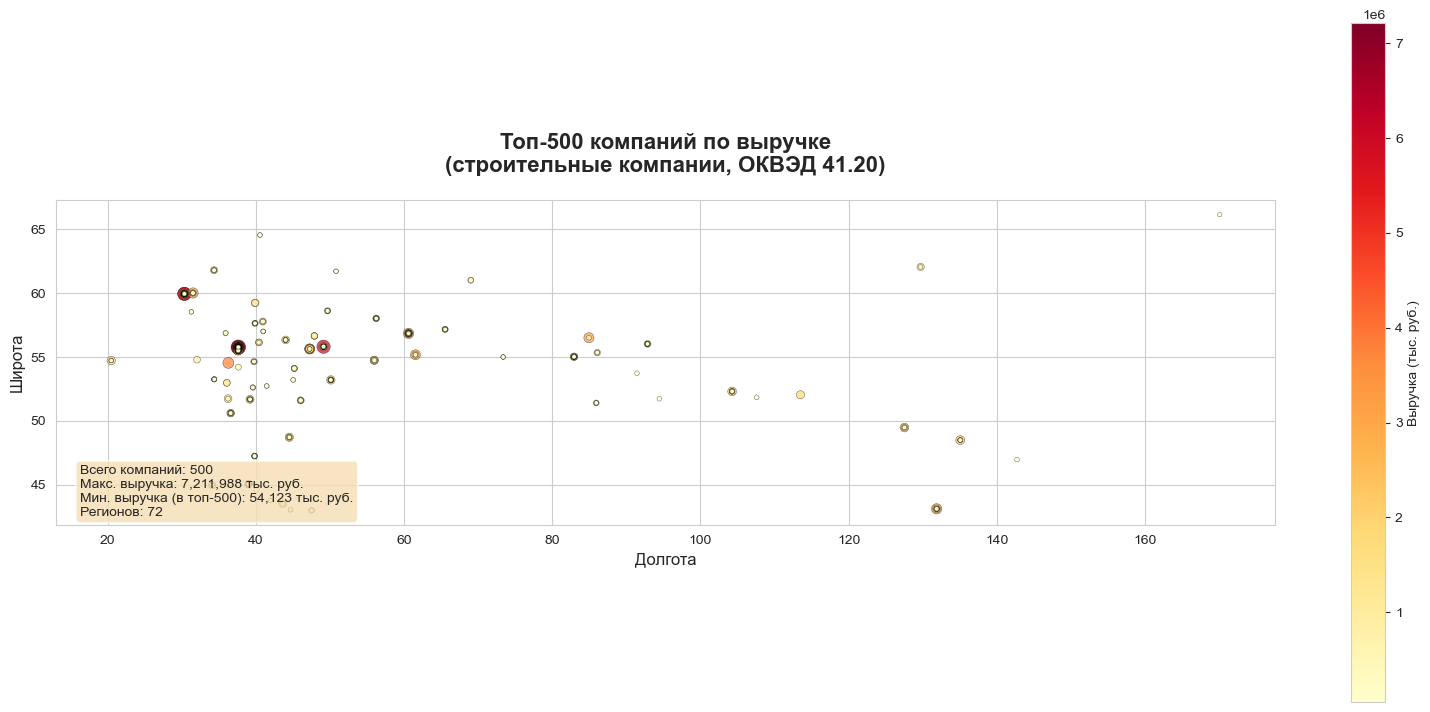


Топ-10 регионов по количеству компаний:
  Москва: 111 компаний
  Санкт-Петербург: 49 компаний
  Московская область: 35 компаний
  Республика Татарстан: 22 компаний
  Краснодарский край: 17 компаний
  Свердловская область: 17 компаний
  Новосибирская область: 13 компаний
  Самарская область: 10 компаний
  Красноярский край: 9 компаний
  Приморский край: 9 компаний

Топ-10 регионов по суммарной выручке:
  Москва: 102,242,746 тыс. руб.
  Санкт-Петербург: 37,438,403 тыс. руб.
  Московская область: 17,724,564 тыс. руб.
  Свердловская область: 14,228,204 тыс. руб.
  Республика Татарстан: 12,734,047 тыс. руб.
  Чувашская Республика - Чувашия: 11,950,208 тыс. руб.
  Краснодарский край: 9,280,309 тыс. руб.
  Приморский край: 6,997,682 тыс. руб.
  Новосибирская область: 5,139,367 тыс. руб.
  Ленинградская область: 5,075,664 тыс. руб.


In [98]:
fig, ax = plt.subplots(1, 1, figsize=(16, 10))
   
max_revenue = gdf["Выручка"].max()
min_revenue = gdf["Выручка"].min()


if max_revenue > min_revenue:
    gdf["size"] = ((gdf["Выручка"] - min_revenue) / (max_revenue - min_revenue) * 100 + 10)
else:
    gdf["size"] = 50


gdf.plot(
    ax=ax,
    column="Выручка",
    cmap="YlOrRd",  
    markersize=gdf["size"],
    alpha=0.7,
    edgecolor="black",
    linewidth=0.3,
    legend=True,
    legend_kwds={'label': "Выручка (тыс. руб.)", 'orientation': "vertical", 'shrink': 0.7}
)


plt.title('Топ-500 компаний по выручке\n(строительные компании, ОКВЭД 41.20)', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Долгота', fontsize=12)
plt.ylabel('Широта', fontsize=12)

stats_text = f'Всего компаний: {len(gdf)}\n'
stats_text += f'Макс. выручка: {max_revenue:,.0f} тыс. руб.\n'
stats_text += f'Мин. выручка (в топ-500): {min_revenue:,.0f} тыс. руб.\n'
stats_text += f'Регионов: {gdf["Регион_чистый"].nunique()}'

plt.text(0.02, 0.02, stats_text, transform=ax.transAxes, 
         fontsize=10, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.show()

region_counts = gdf["Регион_чистый"].value_counts().head(10)
print("\nТоп-10 регионов по количеству компаний:")
for region, count in region_counts.items():
    print(f"  {region}: {count} компаний")

region_revenue = gdf.groupby("Регион_чистый")["Выручка"].sum().nlargest(10)
print("\nТоп-10 регионов по суммарной выручке:")
for region, revenue in region_revenue.items():
    print(f"  {region}: {revenue:,.0f} тыс. руб.")